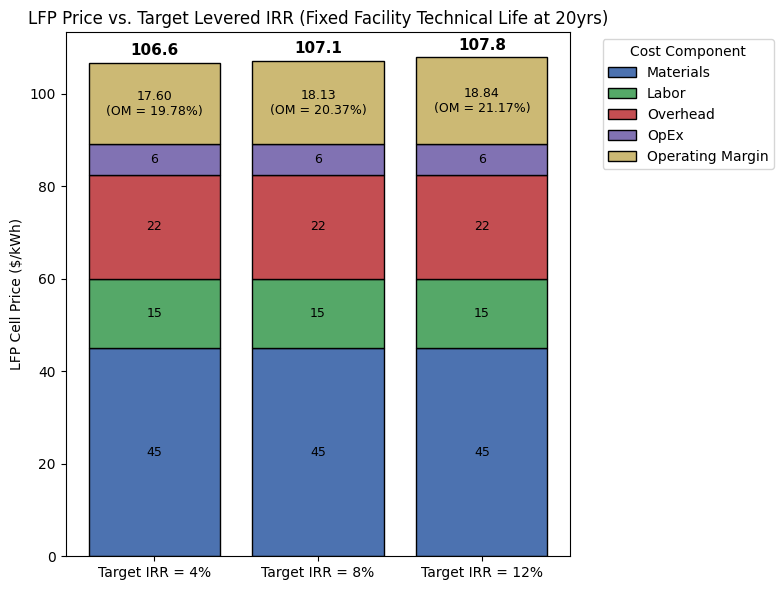

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_file = 'data_batteries/LPF Price vs. Target IRR (Fixed Facility Technical Life).csv'
df = pd.read_csv(csv_file)

# Set first column as index
df = df.set_index(df.columns[0])

components = [
    "Materials ($/kWh)",
    "Labor ($/kWh)",
    "Overhead ($/kWh)",
    "OpEx ($/kWh)",
    "Operating Margin ($/kWh)"
]

plot_df = df.loc[components]
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df = plot_df.T

# Operating margin %
margin_pct = df.loc["Operating Margin (%)"].str.replace("%","").astype(float)

colors = {
    "Materials ($/kWh)": "#4C72B0",
    "Labor ($/kWh)": "#55A868",
    "Overhead ($/kWh)": "#C44E52",
    "OpEx ($/kWh)": "#8172B3",
    "Operating Margin ($/kWh)": "#CCB974"
}

fig, ax = plt.subplots(figsize=(8,6))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df.index))

for comp in components:

    values = plot_df[comp].values

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=comp.replace(" ($/kWh)",""),
        color=colors[comp],
        edgecolor="black"
    )

    for i, bar in enumerate(bars):

        height = bar.get_height()
        y = bottom[i] + height/2

        if comp == "Operating Margin ($/kWh)":
            label = f"{height:.2f}\n(OM = {margin_pct[i]:.2f}%)"
        else:
            label = f"{height:.0f}"

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y,
            label,
            ha="center",
            va="center",
            fontsize=9
        )

    bottom += values


# ----- Add totals on top of bars -----

totals = plot_df.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        x[i],
        total + 1,
        f"{total:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)

ax.set_ylabel("LFP Cell Price ($/kWh)")
#ax.set_xlabel("Target IRR")
ax.set_title("LFP Price vs. Target Levered IRR (Fixed Facility Technical Life at 20yrs)")

ax.legend(title="Cost Component", bbox_to_anchor=(1.05,1))

# Save figure as SVG
plt.savefig(
    "fig_batteries/lfp_price_vs_IRR.svg",
    format="svg",
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

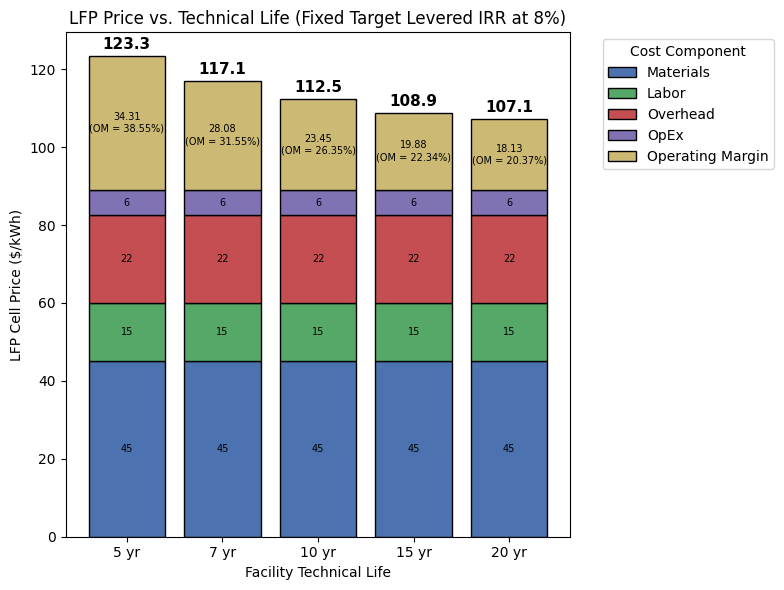

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_file = 'data_batteries/LPF Price vs. Technical Life (Fixed Target IRR at 8%).csv'
df = pd.read_csv(csv_file)

# Set first column as index
df = df.set_index(df.columns[0])

components = [
    "Materials ($/kWh)",
    "Labor ($/kWh)",
    "Overhead ($/kWh)",
    "OpEx ($/kWh)",
    "Operating Margin ($/kWh)"
]

plot_df = df.loc[components]
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df = plot_df.T

# Operating margin %
margin_pct = df.loc["Operating Margin (%)"].str.replace("%","").astype(float)

colors = {
    "Materials ($/kWh)": "#4C72B0",
    "Labor ($/kWh)": "#55A868",
    "Overhead ($/kWh)": "#C44E52",
    "OpEx ($/kWh)": "#8172B3",
    "Operating Margin ($/kWh)": "#CCB974"
}

fig, ax = plt.subplots(figsize=(8,6))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df.index))

for comp in components:

    values = plot_df[comp].values

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=comp.replace(" ($/kWh)",""),
        color=colors[comp],
        edgecolor="black"
    )

    for i, bar in enumerate(bars):

        height = bar.get_height()
        y = bottom[i] + height/2

        if comp == "Operating Margin ($/kWh)":
            label = f"{height:.2f}\n(OM = {margin_pct[i]:.2f}%)"
        else:
            label = f"{height:.0f}"

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y,
            label,
            ha="center",
            va="center",
            fontsize=7
        )

    bottom += values


# ----- totals on top -----

totals = plot_df.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        x[i],
        total + 1,
        f"{total:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# Clean x labels
life_labels = [f"{int(v)} yr" for v in df.loc["Facility Technical Life (Yr)"]]

ax.set_xticks(x)
ax.set_xticklabels(life_labels)

ax.set_ylabel("LFP Cell Price ($/kWh)")
ax.set_xlabel("Facility Technical Life")
ax.set_title("LFP Price vs. Technical Life (Fixed Target Levered IRR at 8%)")

ax.legend(title="Cost Component", bbox_to_anchor=(1.05,1))

plt.tight_layout()

# Save figure
plt.savefig(
    "fig_batteries/lfp_price_vs_technical_life.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

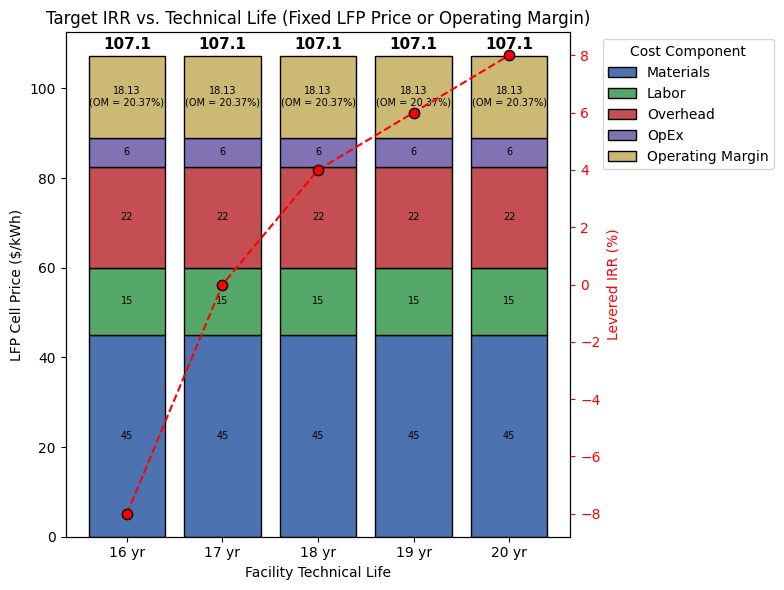

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_file = 'data_batteries/Target IRR vs. Technical Life (Fixed LFP Price or Operating Margin).csv'
df = pd.read_csv(csv_file)

# Set first column as index
df = df.set_index(df.columns[0])

components = [
    "Materials ($/kWh)",
    "Labor ($/kWh)",
    "Overhead ($/kWh)",
    "OpEx ($/kWh)",
    "Operating Margin ($/kWh)"
]

plot_df = df.loc[components]
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')
plot_df = plot_df.T

# Operating margin %
margin_pct = df.loc["Operating Margin (%)"].str.replace("%","").astype(float)

# IRR values
irr = df.loc["IRR (%)"].str.replace("%","").astype(float)

colors = {
    "Materials ($/kWh)": "#4C72B0",
    "Labor ($/kWh)": "#55A868",
    "Overhead ($/kWh)": "#C44E52",
    "OpEx ($/kWh)": "#8172B3",
    "Operating Margin ($/kWh)": "#CCB974"
}

fig, ax = plt.subplots(figsize=(8,6))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df.index))

for comp in components:

    values = plot_df[comp].values

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=comp.replace(" ($/kWh)",""),
        color=colors[comp],
        edgecolor="black"
    )

    for i, bar in enumerate(bars):

        height = bar.get_height()
        y = bottom[i] + height/2

        if comp == "Operating Margin ($/kWh)":
            label = f"{height:.2f}\n(OM = {margin_pct[i]:.2f}%)"
        else:
            label = f"{height:.0f}"

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y,
            label,
            ha="center",
            va="center",
            fontsize=7
        )

    bottom += values


# ----- totals above bars -----

totals = plot_df.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        x[i],
        total + 1,
        f"{total:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# X labels
life_labels = [f"{int(v)} yr" for v in df.loc["Facility Technical Life (Yr)"]]

ax.set_xticks(x)
ax.set_xticklabels(life_labels)

ax.set_ylabel("LFP Cell Price ($/kWh)")
ax.set_title("Target IRR vs. Technical Life (Fixed LFP Price or Operating Margin)")

ax.legend(title="Cost Component", bbox_to_anchor=(1.05,1))


# ---- SECOND Y AXIS FOR IRR ----

ax2 = ax.twinx()

ax2.scatter(
    x,
    irr,
    color="red",
    s=55,
    zorder=5,
    edgecolor = "black"
)

ax2.plot(
    x,
    irr,
    color="red",
    linewidth=1.5,
    linestyle="--",
)

ax2.set_ylabel("Levered IRR (%)", color="red")
ax.set_xlabel("Facility Technical Life")
ax2.tick_params(axis='y', colors='red')


plt.tight_layout()

# Save figure
plt.savefig(
    "fig_batteries/irr_vs_technical_life.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()